In [ ]:
# 2025.11.28~ XGB, LSVM Find HyperOpt & Train Result

In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [25]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu

import importlib
from utils import modeling
importlib.reload(modeling)

from utils import modeling      as mo

In [3]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [4]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [5]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [6]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [7]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [8]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [9]:
#6 하이퍼파라미터
tuner = uu.HyperOptTuner(max_evals=100, random_state=team_rs)

In [11]:
# 모델별 스페이스 생성 : 예시는 catboost 
# learning_rate (0.01–0.2), max_depth (3–10), n_estimators (100–1000), subsample (0.5–1.0), colsample_bytree (0.5–1.0)    
xgb_search_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 1000, 50),
    'subsample': hp.quniform('subsample', 0.5, 1.0, 0.1),  
    'max_depth': hp.quniform('max_depth', 3, 10, 1), 
    'learning_rate': hp.loguniform('learning_rate', np.log(0.001), np.log(0.3)),  # 수정: loguniform이 더 적합
    'colsample_bytree': hp.quniform('colsample_bytree', 0.5, 1.0, 0.1),  
    'scale_pos_weight': hp.quniform('scale_pos_weight', 1, 100, 1),  
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),  
    'gamma': hp.uniform('gamma', 0, 5),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(10)),  # 수정: 0 제외, 범위 확대
    'reg_lambda': hp.loguniform('reg_lambda', np.log(0.001), np.log(10)),  # 수정: loguniform 사용
}

# 모델 생성
xgb_clf = XGBClassifier()

# 파라미터 지정
best_params, best_xgm, trials, exec_time = tuner.tune(
    xgb_clf, X_tr, y_tr, X_val, y_val, xgb_search_space
)


# best모델로 결과출력
# 모델명 규칙 : 2~3자리 모델명 + _ho_best
# model_name = 'xgb_ho_best2_over'
result_over_text = '''
'''



XGBClassifier 튜닝 시작
100%|██████████| 100/100 [03:16<00:00,  1.97s/trial, best loss: -0.8607594936708861]

튜닝 시간: 196.95초
최적 recall: 0.8608

최적 모델의 전체 평가 점수:
- roc_auc: 0.9853
- f1: 0.6461
- precision: 0.5171
- recall: 0.8608
- accuracy: 0.9984


In [12]:
model_name = 'xgb_ho_best'
results[model_name] = uu.get_model_train_eval(
    best_xgm, model_name, X_train, X_test, y_train, y_test, best_params
)


✓ 모델 저장 완료: ../models\xgb_ho_best.pkl
  파일 크기: 0.17 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9682, '정확도': 0.9980, '정밀도': 0.4511, '재현율': 0.8469, 'F1': 0.5887 }
{'오차행렬':
[[56763   101]
 [   15    83]] }
실행 시간: 1.0503449440002441
하이퍼파라미터: {'colsample_bytree': 1.0, 'gamma': 1.7089112007254605, 'learning_rate': 0.038583724829444874, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 150, 'reg_alpha': 0.5940048544595263, 'reg_lambda': 0.007186370173139192, 'scale_pos_weight': 82.0, 'subsample': 0.6000000000000001, 'random_state': 23}


In [ ]:
results['xgb_ho_over_best'] = {'AUC': 0.9721, '정확도': 0.9996, '정밀도': 0.9419, '재현율': 0.8265, 'F1': 0.8804 }
results['xgb_ho_over_best2'] = {'AUC': 0.9731, '정확도': 0.9994, '정밀도': 0.8100, '재현율': 0.8265, 'F1': 0.8182 }
#del results['xgb_ho_over_best_over']

In [ ]:
best_params

{'colsample_bytree': 1.0,
 'gamma': 1.7089112007254605,
 'learning_rate': 0.038583724829444874,
 'max_depth': 3,
 'min_child_weight': 6,
 'n_estimators': 150,
 'reg_alpha': 0.5940048544595263,
 'reg_lambda': 0.007186370173139192,
 'scale_pos_weight': 82.0,
 'subsample': 0.6000000000000001,
 'random_state': 23}

In [ ]:
model_name = 'xgb_ho_tr_over_best'
results[model_name] = uu.get_model_train_eval(
    best_xgm, model_name, X_tr_over, X_test, y_tr_over, y_test, best_params
)


In [38]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기 
xgb_best_params = best_params

X_train_sscaled, X_test_sscaled, scaler = pp.scale_data(X_train, X_test)



In [ ]:
model_name = 'xgb_ho_ssaled_best'
results[model_name] = uu.get_model_train_eval(
    best_xgm, model_name, X_train_sscaled, X_test_sscaled, y_train, y_test, best_params
)


✓ 모델 저장 완료: ../models\xgb_ho_ssaled_best.pkl
  파일 크기: 0.17 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9682, '정확도': 0.9980, '정밀도': 0.4511, '재현율': 0.8469, 'F1': 0.5887 }
{'오차행렬':
[[56763   101]
 [   15    83]] }
실행 시간: 1.103025197982788
하이퍼파라미터: {'colsample_bytree': 1.0, 'gamma': 1.7089112007254605, 'learning_rate': 0.038583724829444874, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 150, 'reg_alpha': 0.5940048544595263, 'reg_lambda': 0.007186370173139192, 'scale_pos_weight': 82.0, 'subsample': 0.6000000000000001, 'random_state': 23}


In [39]:
# Data Scale2 
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_rscaled = scaler.fit_transform(X_train)   # 학습 데이터로 fit + transform
X_test_rscaled = scaler.transform(X_test)         # 테스트 데이터는 transform만

model_name = 'xgb_ho_rsaled_best'
results[model_name] = uu.get_model_train_eval(
    best_xgm, model_name, X_train_rscaled, X_test_rscaled, y_train, y_test, best_params
)


✓ 모델 저장 완료: ../models\xgb_ho_rsaled_best.pkl
  파일 크기: 0.17 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9682, '정확도': 0.9980, '정밀도': 0.4511, '재현율': 0.8469, 'F1': 0.5887 }
{'오차행렬':
[[56763   101]
 [   15    83]] }
실행 시간: 1.0213992595672607
하이퍼파라미터: {'colsample_bytree': 1.0, 'gamma': 1.7089112007254605, 'learning_rate': 0.038583724829444874, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 150, 'reg_alpha': 0.5940048544595263, 'reg_lambda': 0.007186370173139192, 'scale_pos_weight': 82.0, 'subsample': 0.6000000000000001, 'random_state': 23}


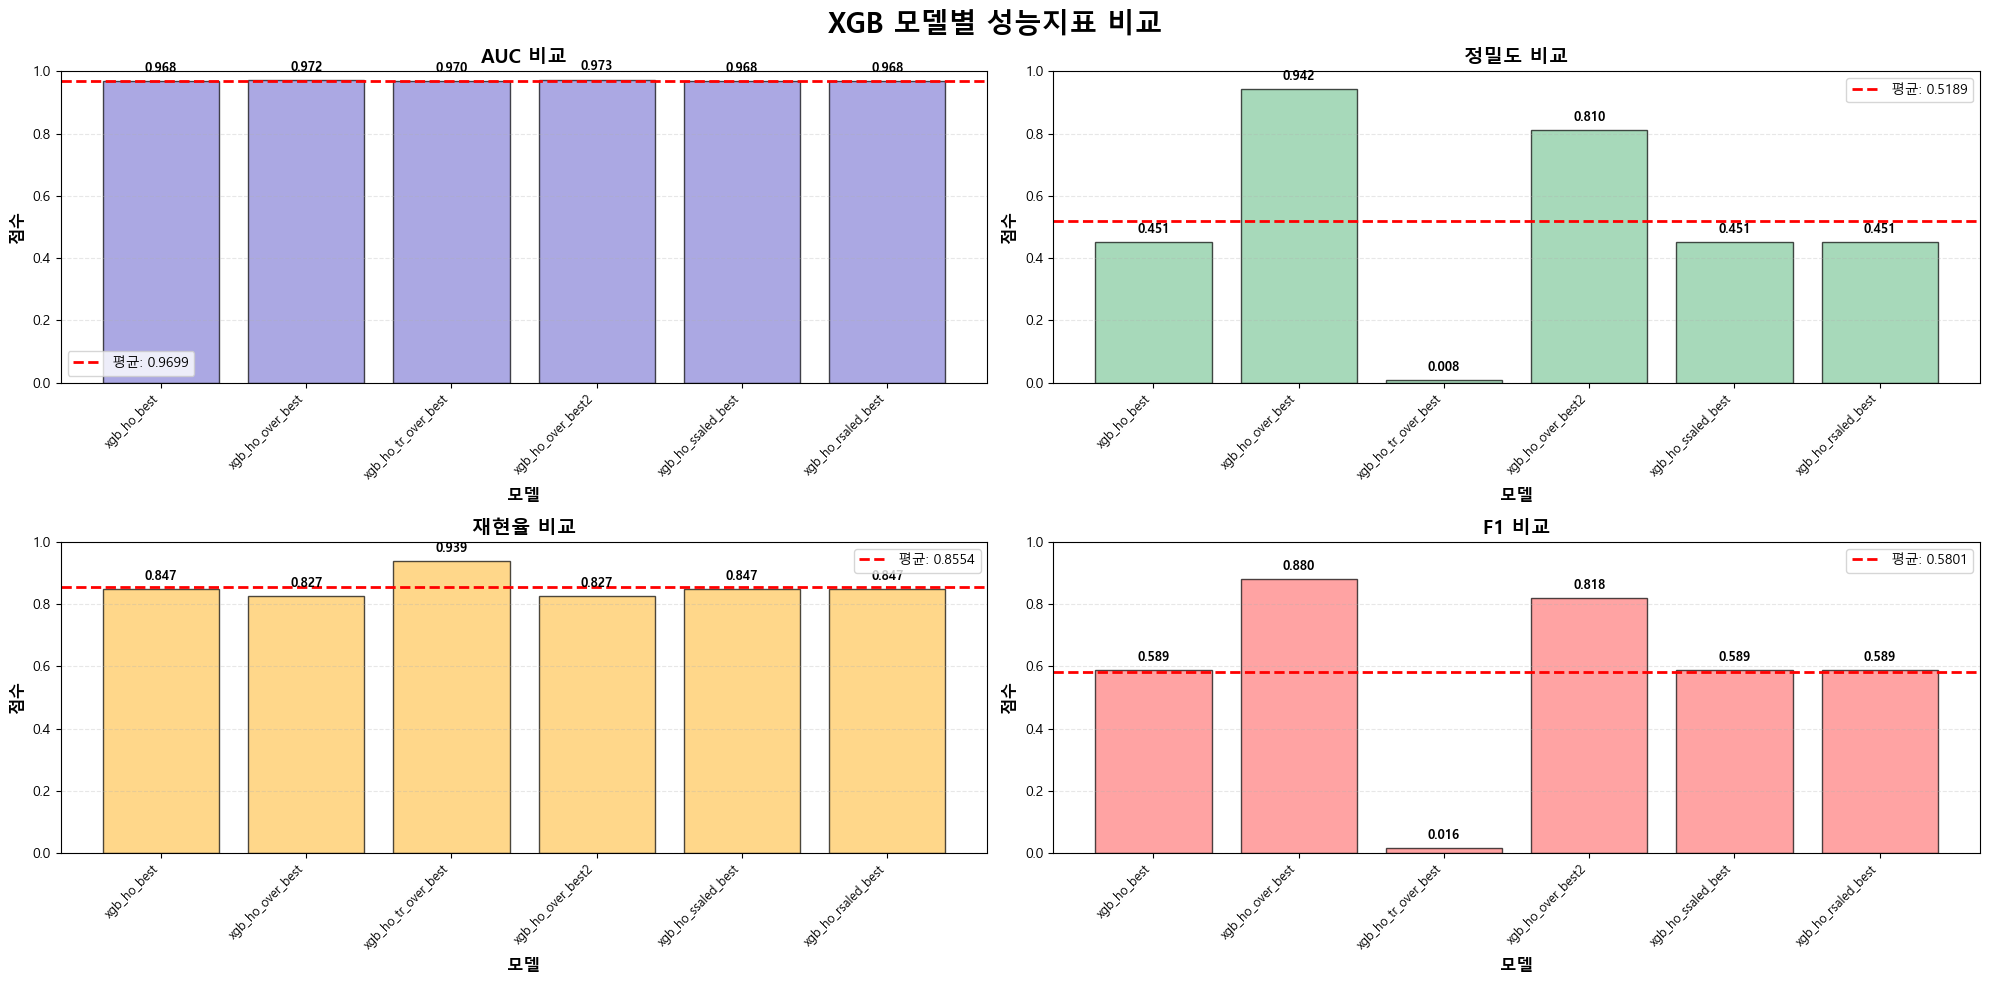


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9731 (xgb_ho_over_best2)
  최저: 0.9682 (xgb_ho_best)
  평균: 0.9699
  표준편차: 0.0022

[정밀도]
  최고: 0.9419 (xgb_ho_over_best)
  최저: 0.0081 (xgb_ho_tr_over_best)
  평균: 0.5189
  표준편차: 0.3281

[재현율]
  최고: 0.9388 (xgb_ho_tr_over_best)
  최저: 0.8265 (xgb_ho_over_best)
  평균: 0.8554
  표준편차: 0.0421

[F1]
  최고: 0.8804 (xgb_ho_over_best)
  최저: 0.0160 (xgb_ho_tr_over_best)
  평균: 0.5801
  표준편차: 0.3051


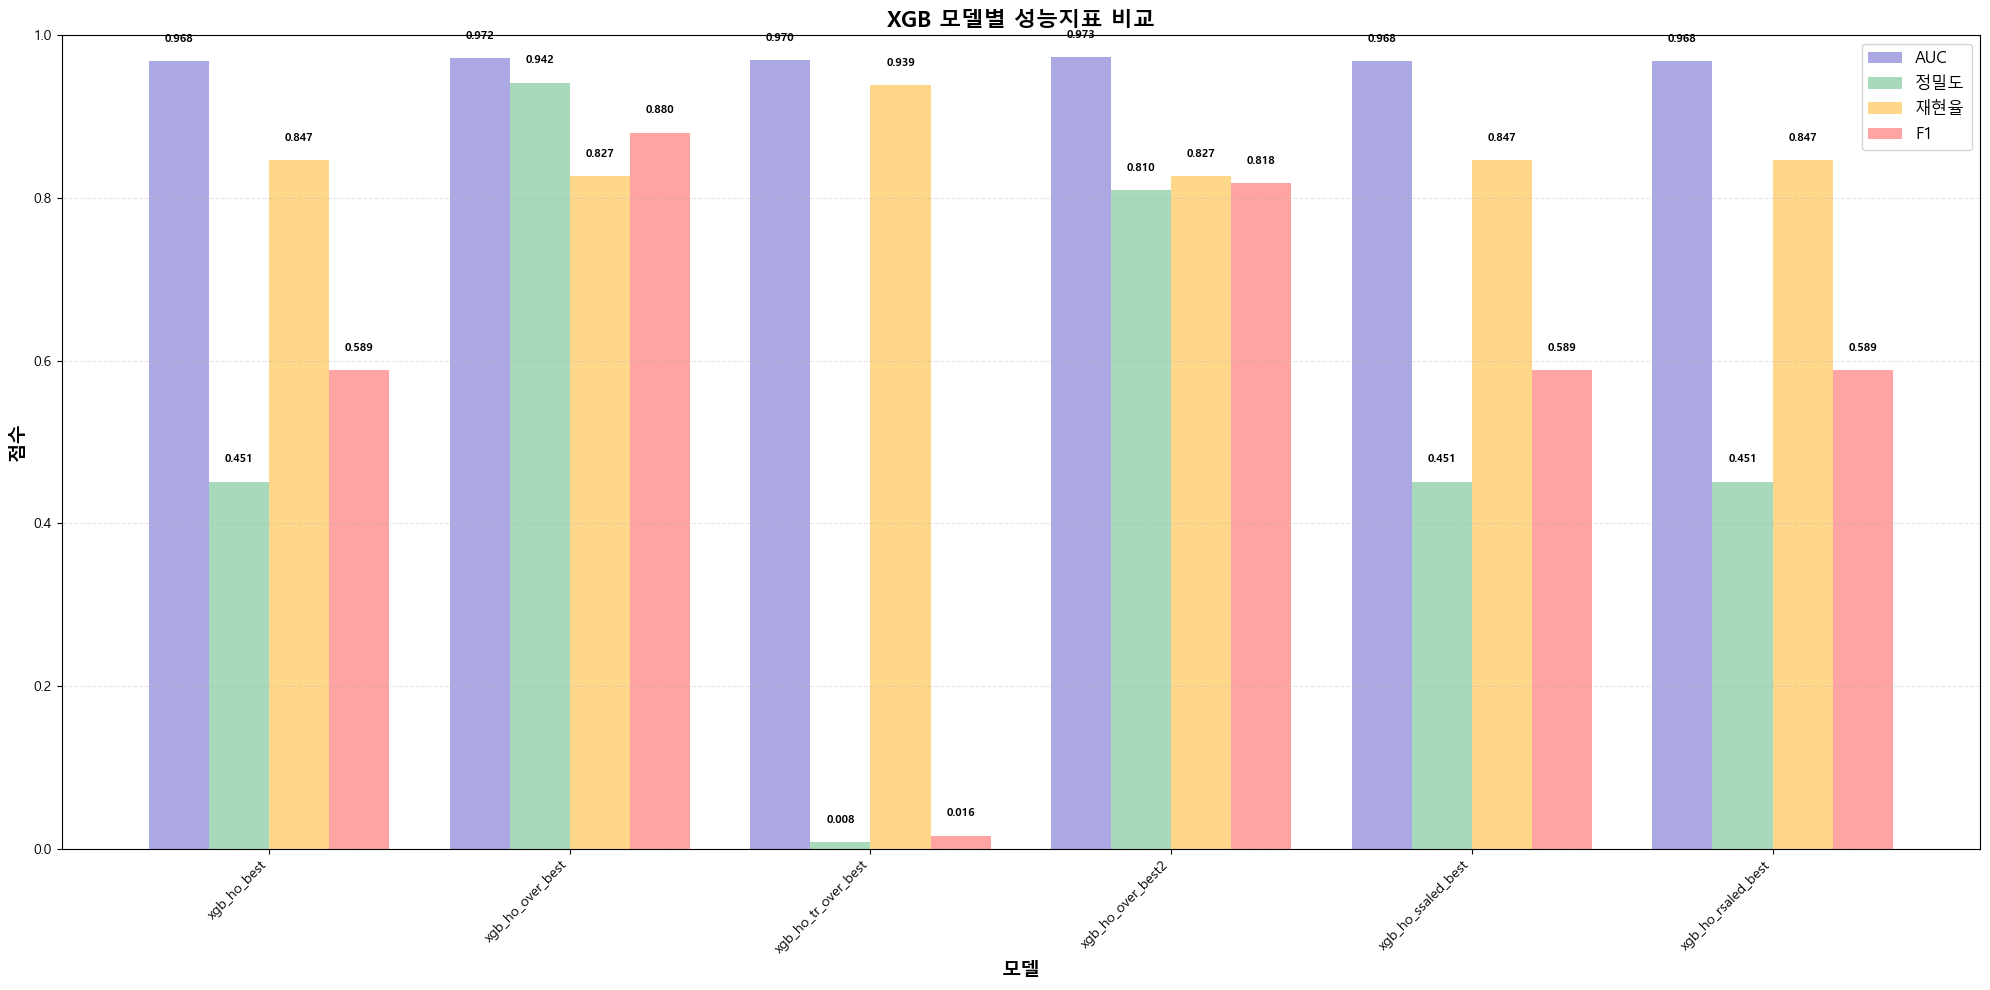


=== F1 Score 기준 상위 5개 모델 ===
                       AUC     정밀도     재현율      F1
xgb_ho_over_best    0.9721  0.9419  0.8265  0.8804
xgb_ho_over_best2   0.9731  0.8100  0.8265  0.8182
xgb_ho_best         0.9682  0.4511  0.8469  0.5887
xgb_ho_ssaled_best  0.9682  0.4511  0.8469  0.5887
xgb_ho_rsaled_best  0.9682  0.4511  0.8469  0.5887

=== AUC 기준 상위 5개 모델 ===
                        AUC     정밀도     재현율      F1
xgb_ho_over_best2    0.9731  0.8100  0.8265  0.8182
xgb_ho_over_best     0.9721  0.9419  0.8265  0.8804
xgb_ho_tr_over_best  0.9697  0.0081  0.9388  0.0160
xgb_ho_best          0.9682  0.4511  0.8469  0.5887
xgb_ho_ssaled_best   0.9682  0.4511  0.8469  0.5887

그래프가 저장되었습니다: ../images/XGB_모델별_성능지표_비교_2025_1129.png


In [40]:
# 7 시각화
mo.model_metrics_graph(results, 'XGB 모델별 성능지표 비교')